<img src="http://www.cidaen.es/assets/img/mCIDaeNnb.png" alt="Logo CiDAEN" align="right">


<br><br><br><br>

<h1><font color="#00586D" size=5>Prueba del modelo entrenado de  YOLOv8 en entorno local</font></h1>
<br><br>


<div align="right">
<font color="#00586D" size=3>Javier de la Ossa</font><br>
<font color="#00586D" size=3>Máster en Ciencia de Datos e Ingeniería de Datos en la Nube</font><br>
<font color="#00586D" size=3>Universidad de Castilla-La Mancha</font>

</div>

---
<a id="indice"></a>
<h2><font color="#00586D" size=5>Índice</font></h2>


* [1. Carga de una imagen de muestra](#section1)
* [2. Carga del modelo](#section2)
* [3. Inferencia y visualización de los resultados](#section3)
* [4. Almacenamiento de las clases detectadas](#section4)

<br>

---

In [1]:
from ultralytics import YOLO
import easyocr
import pytesseract
import numpy as np
import json
import cv2
import matplotlib.pyplot as plt

---

<a id="section1"></a>
## <font color="#00586D"> 1. Carga de un imagen de muestra</font>
<br>

Height: 2732 pixels.
Width: 1700 pixels.


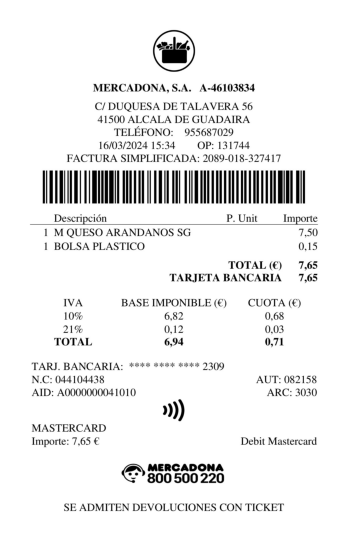

In [2]:
# load the image
img_path = "../../data/digital/valid/images/mercadona_00004_png.rf.ff13aca2da4379ce4803363b5aa19e7b.jpg"

orig_img = cv2.imread(img_path)

# convert BGR to RGB for correct color display in matplotlib
orig_img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

# get and print out the image's dimensions
height, width, _ = orig_img_rgb.shape
print(f"Height: {height} pixels.")
print(f"Width: {width} pixels.")

dpi = 400
figsize = (width / dpi, height / dpi)

plt.figure(figsize=figsize)
plt.imshow(orig_img_rgb)
plt.axis("off")
plt.show()

<a id="section2"></a>
## <font color="#00586D"> 2. Carga del modelo</font>
<br>

In [3]:
# load the model
model_path = "../../history/runs/detect/train7/weights/best.pt"
model = YOLO(model_path)
model.info()

Model summary: 225 layers, 3011823 parameters, 0 gradients, 8.2 GFLOPs


[W NNPACK.cpp:61] Could not initialize NNPACK! Reason: Unsupported hardware.


(225, 3011823, 0, 8.1984512)

<a id="section3"></a>
## <font color="#00586D"> 3. Inferencia y visualización de los resultados</font>
<br>

In [4]:
# run single inference
results = model(img_path)


image 1/1 /home/jadelaossa/Workspaces/CIDaeN/tfm/automatic-receipts-recognition/notebooks/local/../../data/digital/valid/images/mercadona_00004_png.rf.ff13aca2da4379ce4803363b5aa19e7b.jpg: 640x416 1 item_description, 2 store_addresss, 1 store_name, 1 total_amount, 1 transaction_datetime, 468.7ms
Speed: 5.0ms preprocess, 468.7ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 416)


In [5]:
infer = {}

for result in results:
    if "boxes" in result._keys and result.boxes is not None:
        infer["boxes"] = result.boxes.numpy().data.tolist()

print(json.dumps(infer, indent=4))

{
    "boxes": [
        [
            390.9798278808594,
            363.7488098144531,
            953.94287109375,
            455.5842590332031,
            0.9687319993972778,
            2.0
        ],
        [
            1105.9249267578125,
            1285.125,
            1632.6719970703125,
            1368.6688232421875,
            0.9631676077842712,
            3.0
        ],
        [
            432.3730773925781,
            669.0873413085938,
            870.9619140625,
            744.0116577148438,
            0.9463440775871277,
            4.0
        ],
        [
            391.7920227050781,
            466.99737548828125,
            1281.975341796875,
            542.9600219726562,
            0.9267165660858154,
            1.0
        ],
        [
            123.32255554199219,
            1123.3065185546875,
            1642.73974609375,
            1201.5338134765625,
            0.7601867914199829,
            0.0
        ],
        [
            394.

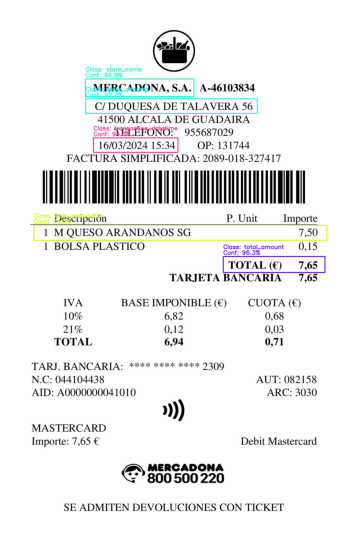

In [6]:
# import random

classes_mapper = {0: "item_description", 1: "store_address", 2: "store_name", 3: "total_amount", 4: "transaction_datetime"}

image_height, image_width, _ = orig_img.shape
# Usually the model height and width are necessary to place the bbox according to the original image size
# but in this case x1, x2, y1, y2 are given scaled to the original image size
model_height, model_width = image_height, image_width   # 640 x 352
x_ratio = image_width / model_width # x and y ratios are 1
y_ratio = image_height / model_height

img_with_boxes = orig_img.copy()

if "boxes" in infer:
    for idx, (x1, y1, x2, y2, conf, lbl) in enumerate(infer["boxes"]):
        # Scale bounding box coordinates back to the original image size
        x1, x2 = int(x_ratio * x1), int(x_ratio * x2)
        y1, y2 = int(y_ratio * y1), int(y_ratio * y2)

        # Map label int with its text value
        lbl_name = classes_mapper.get(lbl)

        # Choose a color for the bounding box
        if lbl_name == "item_description":
            color = (0, 255, 206)
        elif lbl_name == "store_address":
            color = (255, 255, 0)
        elif lbl_name == "store_name":
            color = (199, 252, 0)
        elif lbl_name == "total_amount":
            color = (254, 0, 86)
        else:
            color = (134, 34, 255)  
        
        # color = (random.randint(10, 255), random.randint(10, 255), random.randint(10, 255))
        
        if conf > 0.5:
            # Draw the bounding box
            cv2.rectangle(img_with_boxes, (x1, y1), (x2, y2), color, 4)
            
            # Put label and confidence on the image
            cv2.putText(img_with_boxes, f"Class: {lbl_name}", (x1, y1 - 40), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2, cv2.LINE_AA)
            cv2.putText(img_with_boxes, f"Conf: {conf * 100:.1f}%", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2, cv2.LINE_AA)

dpi = 400
figsize = (image_width / dpi, image_height / dpi)

# Display the image with bounding boxes
plt.figure(figsize=figsize)
plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
plt.axis("off")  # Turn off axis
plt.show()

<a id="section4"></a>
## <font color="#00586D"> 4. Almacenamiento de las clases detectadas</font>
<br>

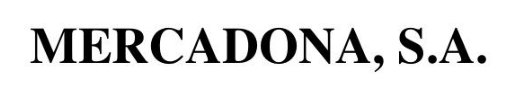

True

In [7]:
import os

# Example of how to save a single crop
# [
#     408.9201354980469,    # x1
#     368.6069641113281,    # y1
#     960.4403686523438,    # x2
#     447.503662109375,     # y2
#     0.9523453116416931,   # conf
#     2.0                   # class
# ]

# Example of bbox and classes
x1 = int(408.9201354980469)
x2 = int(960.4403686523438)
y1 = int(368.6069641113281)
y2 = int(447.503662109375)

lbl_name = classes_mapper.get(2)

# Crop the image
cropped_img = orig_img[y1:y2, x1:x2]

# Convert the cropped image from BGR to RGB for display
cropped_img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)

# Display the cropped image
plt.imshow(cropped_img_rgb)
plt.axis("off")
plt.show()

# Save the cropped image to a file
CROPS_DIR = f"./crops/{img_path.split('/')[-1][:20]}/{lbl_name}"

# Create directory if it does not exist
os.makedirs(CROPS_DIR, exist_ok=True)

# Define the output file path
output_path = f"{CROPS_DIR}/detection_1.png"

# Save the cropped image to the file
cv2.imwrite(output_path, cropped_img)

In [8]:
classes_mapper = {0: "item_description", 1: "store_address", 2: "store_name", 3: "total_amount", 4: "transaction_datetime"}

image_height, image_width, _ = orig_img.shape
model_height, model_width = image_height, image_width
x_ratio = image_width / model_width # x and y ratios are 1
y_ratio = image_height / model_height

counters = {"item_description": 0, "store_address": 0, "store_name": 0, "total_amount": 0, "transaction_datetime": 0}

if "boxes" in infer:
    for idx, (x1, y1, x2, y2, conf, lbl) in enumerate(infer["boxes"]):
        # If confidence below 0.5, don't save the crop
        if conf < 0.5:
            continue

        # Map lbl with class name
        lbl_name = classes_mapper.get(lbl)

        # Choose a color for the bounding box
        if lbl_name in counters:
            counters[lbl_name] += 1
            counter = counters[lbl_name]
                                      
        # Scale bounding box coordinates back to the original image size
        x1, x2 = int(x_ratio * x1), int(x_ratio * x2)
        y1, y2 = int(y_ratio * y1), int(y_ratio * y2)

        # Crop the image
        cropped_img = orig_img[y1:y2, x1:x2]

        # Convert the cropped image from BGR to RGB for display
        cropped_img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)

        # Save the cropped image to a file
        CROPS_DIR = f"./crops/{img_path.split('/')[-1]}/{lbl_name}"

        # Create directory if it does not exist
        os.makedirs(CROPS_DIR, exist_ok=True)

        # Define the output file path
        output_path = f"{CROPS_DIR}/detection_{counter}.png"

        # Save the cropped image to the file
        cv2.imwrite(output_path, cropped_img_rgb)

summary_txt = f"""
{counters['item_description']} item_description, {counters['store_address']} store_address, \
{counters['store_name']} store_name, {counters['total_amount']} total_amount and \
{counters['transaction_datetime']} transaction_datetime have been saved under ./crops
"""
print(summary_txt)


1 item_description, 1 store_address, 1 store_name, 1 total_amount and 1 transaction_datetime have been saved under ./crops

